# Host and Availability Analysis

This notebook explores host behavior patterns and listing availability across NYC Airbnb market. We analyze professional vs casual hosts, their pricing strategies, geographic distribution, and availability patterns by Neigbourhood Group and room type.

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv('../data/processed/processed_listings.csv')

In [82]:
# Total number of listings
df.shape[0]

48884

In [83]:
# Total number of listings per host
top_hosts = df["host_id"].value_counts().head(10)

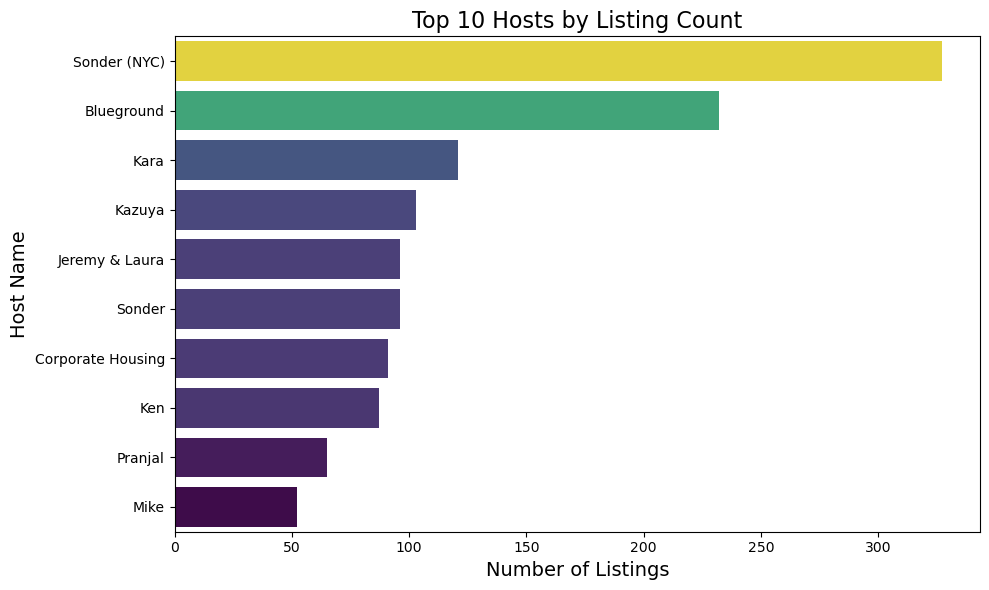

In [84]:
# Visualize top 10 hosts by listing count
host_names = df.drop_duplicates('host_id').set_index('host_id')['host_name']
top_hosts_names = top_hosts.index.map(lambda x: host_names.get(x, f'Host {x}'))

plt.figure(figsize=(10, 6))
sns.barplot(y=top_hosts_names, x=top_hosts.values, hue=top_hosts.values, palette='viridis', legend=False)
plt.xlabel("Number of Listings", fontsize=14)
plt.ylabel("Host Name", fontsize=14)
plt.title("Top 10 Hosts by Listing Count", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/top_hosts_by_listing_count.png", dpi=150, bbox_inches="tight")
plt.show()

In [85]:
# Create a new column for professional hosts (those with more than 1 listing)
df["professional_host"] = df["calculated_host_listings_count"] > 1

In [86]:
# Total number of hosts
df["host_id"].nunique()

37455

In [87]:
# Average price for professional vs non-professional hosts
avg_price =df.groupby("professional_host")["price"].mean().reset_index()

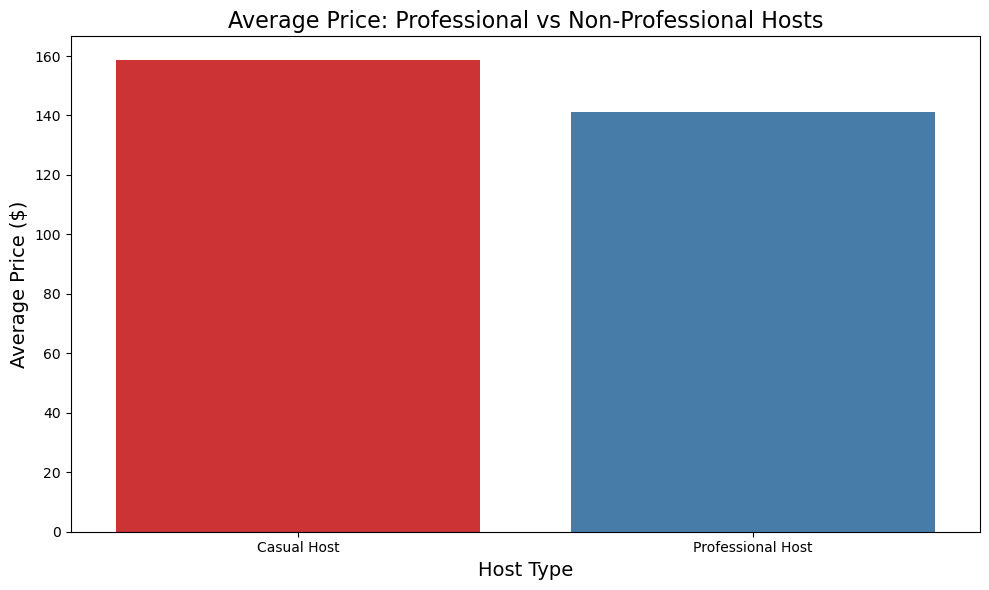

In [88]:
# Visualize price comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price, x="professional_host", y="price", estimator="mean", palette="Set1", hue="professional_host", legend=False)
plt.xlabel("Host Type", fontsize=14)
plt.ylabel("Average Price ($)", fontsize=14)
plt.title("Average Price: Professional vs Non-Professional Hosts", fontsize=16)
plt.xticks([0, 1], ["Casual Host", "Professional Host"])
plt.tight_layout()
plt.savefig("../outputs/price_by_host_type.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
# Cross-tabulation of neighbourhood group and professional host status
crosstab_data = pd.crosstab(df["neighbourhood_group"], df["professional_host"]).reset_index()

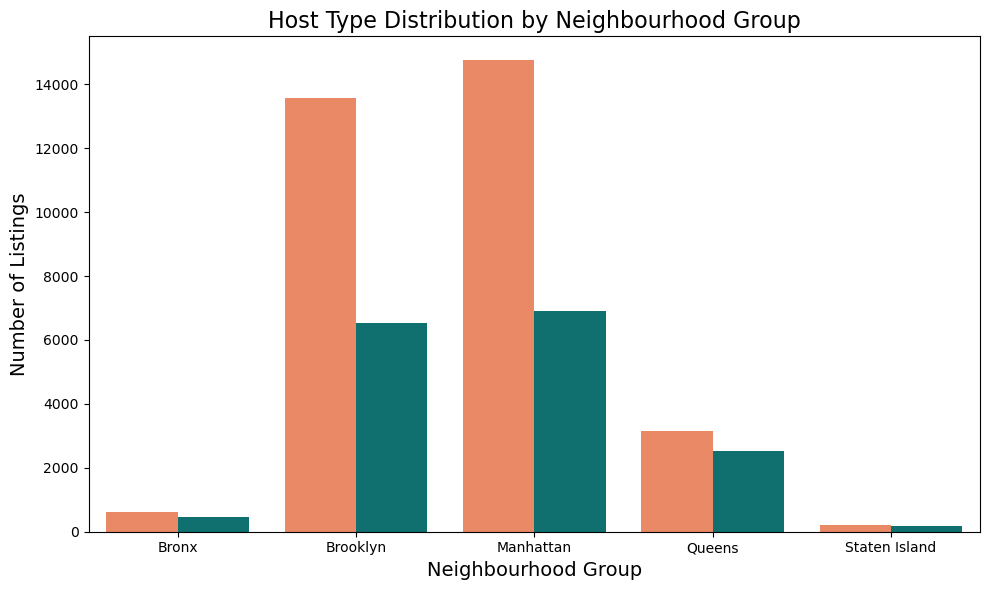

In [90]:
# Visualize host distribution by neigbourhood_group
crosstab_melted = crosstab_data.melt(id_vars="neighbourhood_group", var_name="professional_host", value_name="count")

plt.figure(figsize=(10, 6))
sns.barplot(data=crosstab_melted, x="neighbourhood_group", y='count', hue="professional_host", palette=['coral', 'teal'], legend=False)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.ylabel("Number of Listings", fontsize=14)
plt.title("Host Type Distribution by Neighbourhood Group", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/host_type_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

In [91]:
# Percentage of listings by neighbourhood group and professional host status
pd.crosstab(df["neighbourhood_group"], df["professional_host"], normalize='index') * 100

professional_host,False,True
neighbourhood_group,,
Bronx,57.064220,42.935780
Brooklyn,67.554118,32.445882
Manhattan,68.148661,31.851339
Queens,55.506530,44.493470
Staten Island,53.083110,46.916890


In [92]:
# Checking the neighbourhood group with the highest availability
availability_neighbourhood_group = df.groupby("neighbourhood_group")["availability_365"].mean().reset_index()
availability_neighbourhood_group

,neighbourhood_group,availability_365
0,Bronx,165.794495
1,Brooklyn,100.217318
2,Manhattan,111.984580
3,Queens,144.451818
4,Staten Island,199.678284


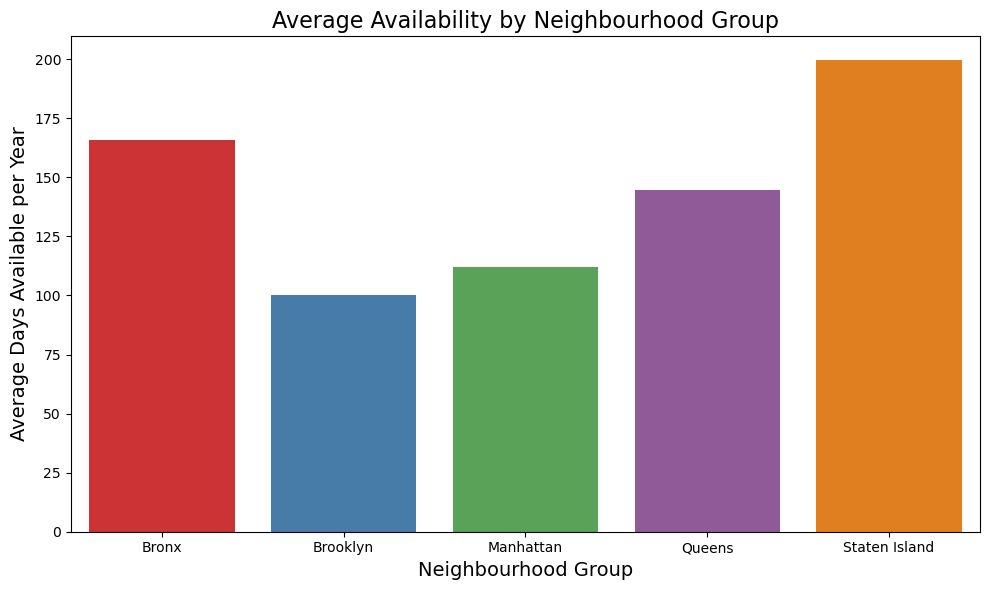

In [93]:
# Visualize availability by neighbourhood_group
plt.figure(figsize=(10, 6))
sns.barplot(data=availability_neighbourhood_group, x="neighbourhood_group", y="availability_365", palette="Set1", hue="neighbourhood_group", legend=False)
plt.ylabel("Average Days Available per Year", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=14)
plt.title("Average Availability by Neighbourhood Group", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/availability_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
# Availability by room type
availablity_by_room_type = df.groupby("room_type")["availability_365"].mean().reset_index()

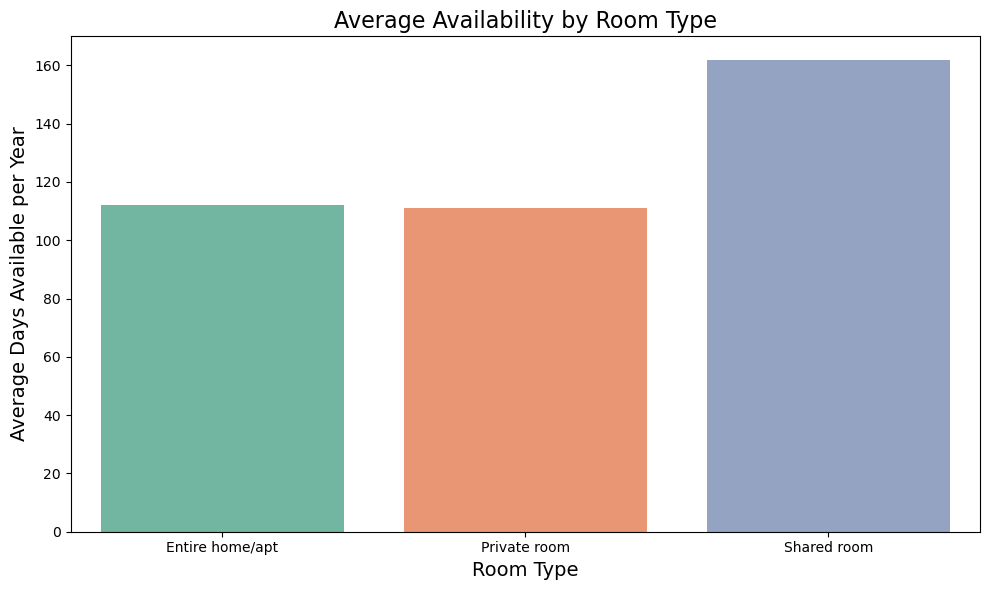

In [95]:
# Visualize availability by room type
plt.figure(figsize=(10, 6))
sns.barplot(data=availablity_by_room_type, x="room_type", y="availability_365", estimator="mean", palette="Set2", hue="room_type", legend=False)
plt.xlabel("Room Type", fontsize=14)
plt.ylabel("Average Days Available per Year", fontsize=14)
plt.title("Average Availability by Room Type", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/availability_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- **66% of listings** belong to casual hosts (single property), while 34% are from professional hosts
- **Casual hosts charge ~$17 more** on average ($159 vs $141) than professional hosts
- **Manhattan and Brooklyn** dominate with 68% casual host concentration
- **Staten Island has highest availability** (200 days/year), suggesting lower demand
- **Shared rooms** have 45% more availability than entire homes/private rooms, indicating weak demand